Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64
              Age         Sex  ChestPainType   RestingBP  Cholesterol  \
count  918.000000  918.000000     918.000000  918.000000   918.000000   
mean    53.510893    0.789760       0.781046  132.396514   198.799564   
std      9.432617    0.407701       0.956519   18.514154   109.384145   
min     28.000000    0.000000       0.000000    0.000000     0.000000   
25%     47.000000    1.000000       0.000000  120.000000   173.250000   
50%     54.000000    1.000000       0.000000  130.000000   223.000000   
75%     60.000000    1.000000       2.000000  140.000000   267.000000   
max     77.000000    1.000000       3.000000  200.000000   603.000000   

        FastingBS  RestingECG       MaxHR  ExerciseAngina     Oldpeak  \
count  918.00000

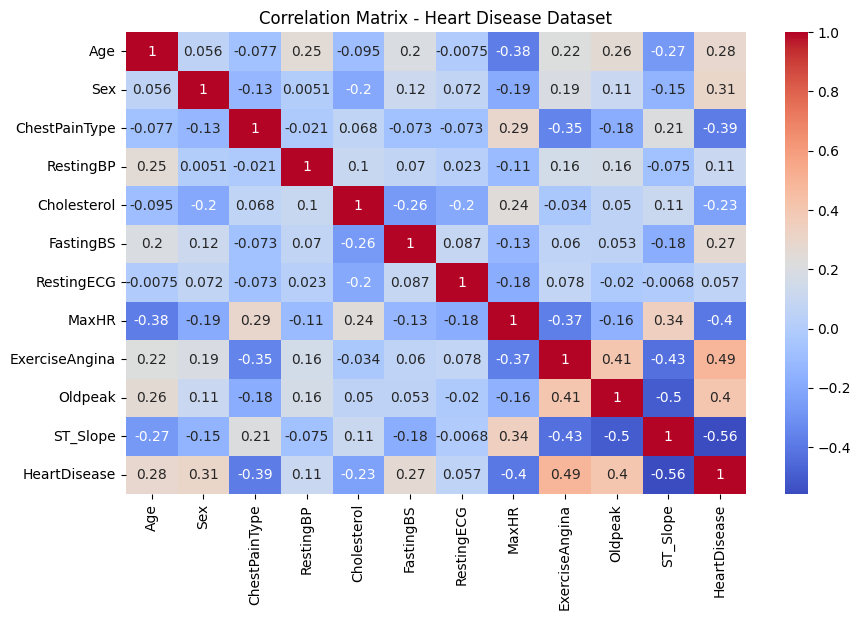

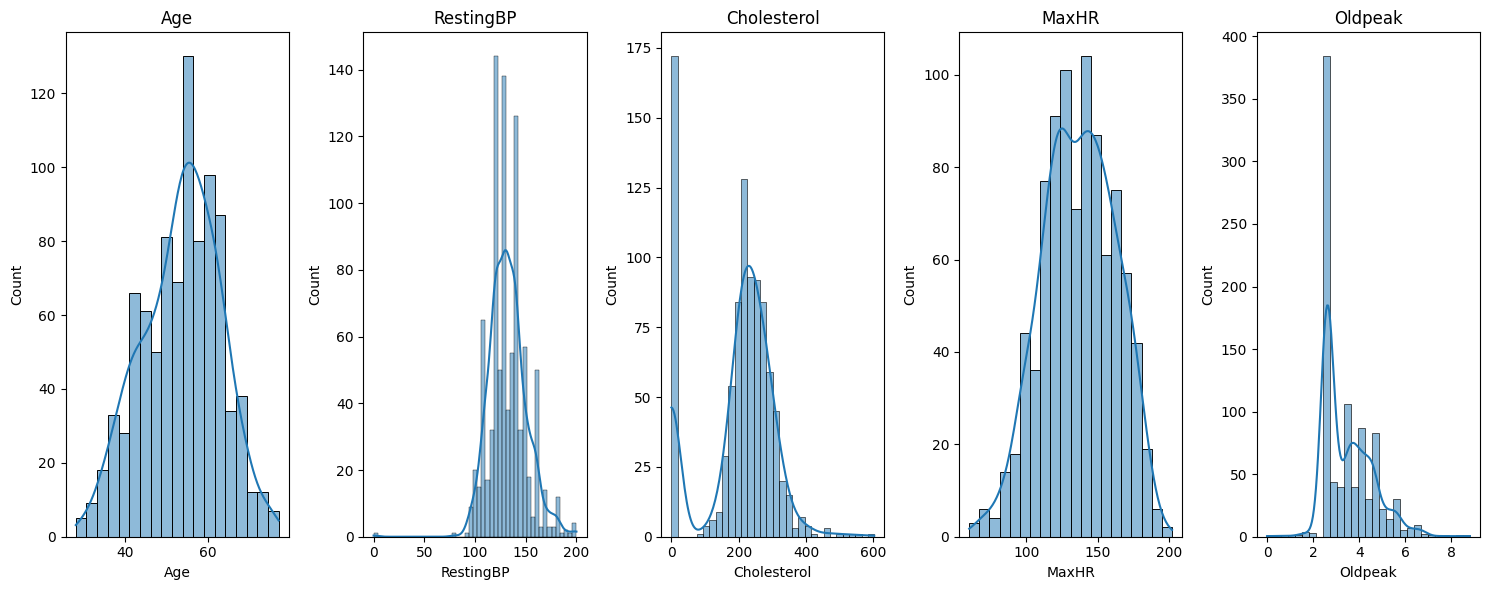

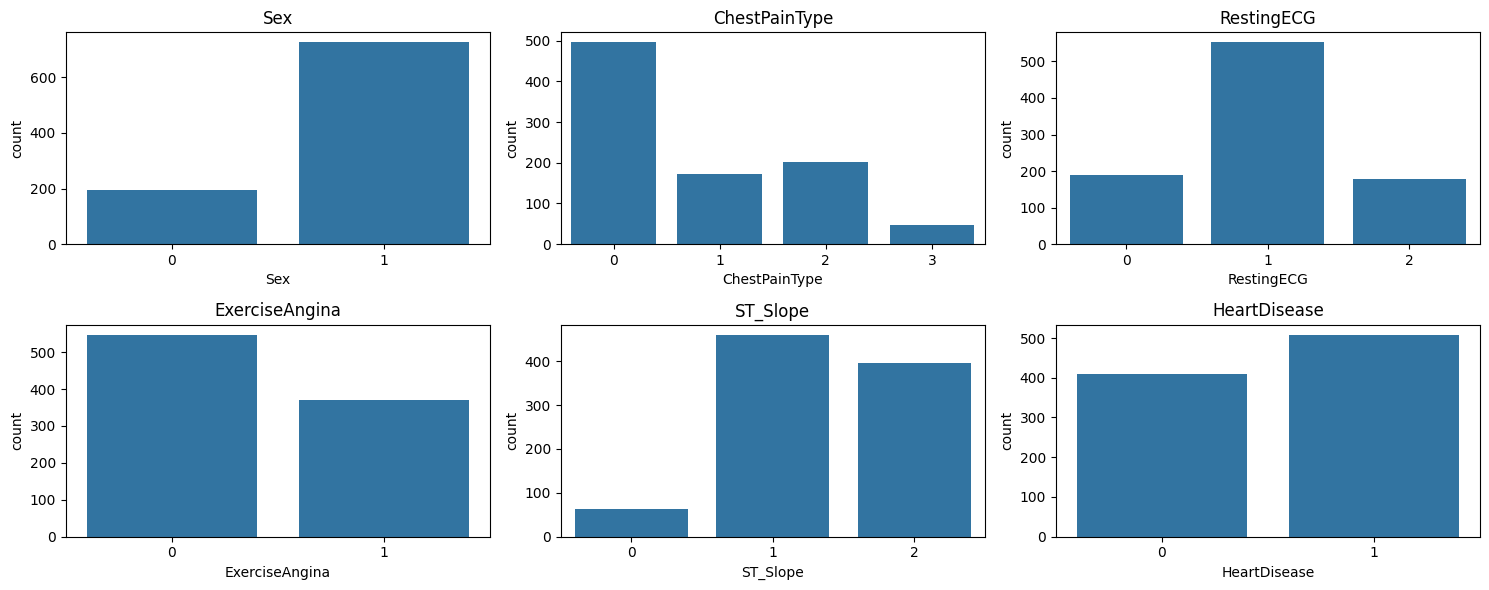

MLP Accuracy: 0.8695652173913043
              precision    recall  f1-score   support

           0       0.88      0.82      0.85        82
           1       0.86      0.91      0.89       102

    accuracy                           0.87       184
   macro avg       0.87      0.86      0.87       184
weighted avg       0.87      0.87      0.87       184

Logistic Regression Accuracy: 0.875
Decision Tree Accuracy: 0.7880434782608695


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Best LR Params: {'C': 1, 'solver': 'lbfgs'}
Best LR Score: 0.8473301649426894
Best DT Params: {'max_depth': 3, 'min_samples_split': 2}
Best DT Score: 0.8364551299972044
Selected Features: Index(['Age', 'ChestPainType', 'Cholesterol', 'FastingBS', 'MaxHR',
       'ExerciseAngina', 'Oldpeak', 'ST_Slope'],
      dtype='object')
Final LR Accuracy: 0.8532608695652174
Final DT Accuracy: 0.8206521739130435
Final MLP Accuracy: 0.8695652173913043


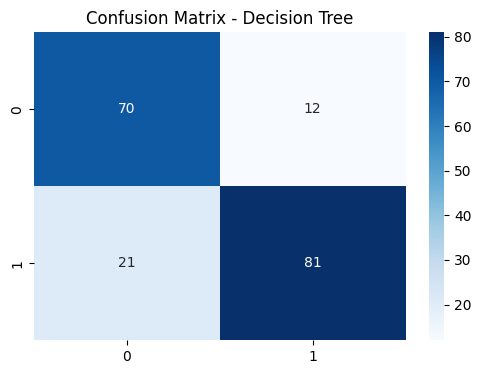

In [ ]:
# =========================================
# 1. IMPORT LIBRARIES
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, chi2

from sklearn.neural_network import MLPClassifier

# =========================================
# 2. LOAD DATA
# =========================================
df = pd.read_csv("heart.csv")  # change path if needed

# =========================================
# 3. DATA CLEANING & PREPROCESSING
# =========================================
# Check for missing values
print(df.isnull().sum())

# Encode categorical columns
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

# Ensure 'Oldpeak' is non-negative for chi2 feature selection
# Shift the 'Oldpeak' column so that its minimum value is 0.
if 'Oldpeak' in df.columns and df['Oldpeak'].min() < 0:
    df['Oldpeak'] = df['Oldpeak'] - df['Oldpeak'].min()

# Inspect summary statistics
print(df.describe())

# =========================================
# 4. EXPLORATORY DATA ANALYSIS
# =========================================
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix - Heart Disease Dataset")
plt.show()

# Distribution plots
plt.figure(figsize=(15,6))
for i, col in enumerate(['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']):
    plt.subplot(1,5,i+1)
    sns.histplot(df[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

# Countplots for categorical features
plt.figure(figsize=(15,6))
for i, col in enumerate(categorical_cols + ['HeartDisease']):
    plt.subplot(2,3,i+1)
    sns.countplot(x=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# =========================================
# 5. SPLIT DATA
# =========================================
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale numeric features for NN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================================
# 6. NEURAL NETWORK MODEL
# =========================================
mlp = MLPClassifier(
    hidden_layer_sizes=(100,50),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=1000,
    early_stopping=True,
    random_state=42,
    verbose=False
)
mlp.fit(X_train_scaled, y_train)

y_pred_nn = mlp.predict(X_test_scaled)
print("MLP Accuracy:", accuracy_score(y_test, y_pred_nn))
print(classification_report(y_test, y_pred_nn))

# =========================================
# 7. CLASSICAL ML MODELS
# =========================================
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Evaluation
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

# =========================================
# 8. HYPERPARAMETER OPTIMIZATION (GridSearchCV)
# =========================================
# Logistic Regression
lr_params = {'C':[0.01,0.1,1,10,100], 'solver':['liblinear','lbfgs']}
lr_grid = GridSearchCV(LogisticRegression(max_iter=1000), lr_params, cv=5, scoring='accuracy')
lr_grid.fit(X_train, y_train)
print("Best LR Params:", lr_grid.best_params_)
print("Best LR Score:", lr_grid.best_score_)

# Decision Tree
dt_params = {'max_depth':[None,3,5,7,10],'min_samples_split':[2,5,10]}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=5, scoring='accuracy')
dt_grid.fit(X_train, y_train)
print("Best DT Params:", dt_grid.best_params_)
print("Best DT Score:", dt_grid.best_score_)

# =========================================
# 9. FEATURE SELECTION
# =========================================
# Using SelectKBest (Chi-Squared) for classification
selector = SelectKBest(score_func=chi2, k=8)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)
selected_features = X.columns[selector.get_support()]
print("Selected Features:", selected_features)

# =========================================
# 10. FINAL MODELS WITH OPTIMAL HYPERPARAMS & FEATURES
# =========================================
# Logistic Regression
final_lr = LogisticRegression(**lr_grid.best_params_, max_iter=1000, random_state=42)
final_lr.fit(X_train_selected, y_train)
y_pred_final_lr = final_lr.predict(X_test_selected)
print("Final LR Accuracy:", accuracy_score(y_test, y_pred_final_lr))

# Decision Tree
final_dt = DecisionTreeClassifier(**dt_grid.best_params_, random_state=42)
final_dt.fit(X_train_selected, y_train)
y_pred_final_dt = final_dt.predict(X_test_selected)
print("Final DT Accuracy:", accuracy_score(y_test, y_pred_final_dt))

# Neural Network (optional: can use all features)
y_pred_final_nn = mlp.predict(X_test_scaled)
print("Final MLP Accuracy:", accuracy_score(y_test, y_pred_final_nn))

# Confusion Matrix for best model
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_final_dt), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Decision Tree")
plt.show()
